# Naija-Speech — Results Analysis & Live Demo

Validate the fine-tuned STT model two ways:

1. **Layer 1 — per-clip receipts** (no GPU needed): join the zero-shot and fine-tuned
   transcripts saved during evaluation and *see* the corrections — plus the honest
   counterpoint (clips fine-tuning made worse).
2. **Layer 2 — live A/B demo**: run the same audio through the base model and the
   base+adapter model side by side. Fast on GPU; workable-but-slow on a laptop CPU.

**Needs:** the unpacked results bundle at `outputs/stt_whisper_turbo_results/`
(adapter + hypotheses CSVs). Layer 1 needs nothing else. Layer 2 downloads the
~1.6 GB base model on first run and streams a few test clips from HF.

In [16]:
import os, sys

# Run from repo root or notebooks/ — normalise to repo root.
if not os.path.exists("outputs") and os.path.exists("../outputs"):
    os.chdir("..")
sys.path.insert(0, "src")

RESULTS = "outputs/stt_whisper_turbo_results/outputs"
ADAPTER = f"{RESULTS}/whisper_turbo_hf/adapter"
assert os.path.exists(f"{RESULTS}/zeroshot/hypotheses.csv"), "results bundle not found!"
print("results bundle OK:", RESULTS)

results bundle OK: outputs/stt_whisper_turbo_results/outputs


## 0 — Install dependencies (one-time; safe to re-run)

Installs into whatever kernel/venv this notebook runs in. **Windows + NVIDIA
note:** plain `pip install torch` gives a CPU-only build — the cell below
detects that and pulls the CUDA wheel instead, so a local GPU (e.g. an RTX
4070 Laptop, 8 GB — plenty for this notebook's fp16 inference) actually gets
used. On Colab, torch already has CUDA and the cell skips straight to the
requirements install.

In [2]:
import importlib.util, subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *args])

# torch: install the CUDA build if torch is absent or CPU-only (Windows trap).
need_cuda_torch = importlib.util.find_spec("torch") is None
if not need_cuda_torch:
    import torch
    need_cuda_torch = not torch.cuda.is_available()
if need_cuda_torch:
    print("installing CUDA torch (~2.5 GB, one time) ...")
    pip("torch", "--index-url", "https://download.pytorch.org/whl/cu124")

pip("-r", "requirements.txt")   # transformers/peft/datasets/librosa/jiwer/...

import torch
print("kernel env:", sys.executable)   # MUST be your project .venv — switch kernel if not
print(f"torch {torch.__version__} | cuda: {torch.cuda.is_available()}"
      + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

installing CUDA torch (~2.5 GB, one time) ...
kernel env: c:\Users\John Michael\Desktop\Remote Engineer\sandbox\Neural Maze Courses\finetuning-course\0\.venv\Scripts\python.exe
torch 2.12.1+cpu | cuda: False


## Layer 1 — join the per-clip transcripts

`hypotheses.csv` was written by both eval scripts: one row per test clip with the
human reference and the model's transcript. Joining on `idx` (same split, same
order, same filters) puts *before* and *after* side by side.

In [3]:
import pandas as pd

b = pd.read_csv(f"{RESULTS}/zeroshot/hypotheses.csv").rename(columns={"hypothesis": "zeroshot"})
a = pd.read_csv(f"{RESULTS}/whisper_turbo_hf/results/hypotheses.csv")[["idx", "hypothesis"]] \
      .rename(columns={"hypothesis": "finetuned"})
j = b.merge(a, on="idx")
print(f"{len(j)} clips | {(j.zeroshot != j.finetuned).sum()} transcripts changed by fine-tuning")
j.head(3)

4452 clips | 4449 transcripts changed by fine-tuning


,idx,reference,zeroshot,macro_accent,domain,finetuned
0,0,The couple concluded their wedding ceremony by...,The couple concluded their wedding ceremony b...,Other,general,the couple concluded their wedding ceremony by...
1,1,Her 22 year old sister Enyinnanya lives w/ her...,"Her 22-year-old sister, Enyi Naya, lives with...",Other,general,her 22 year old sister enyin nanya lives with ...
2,2,Makeup zainabazeez,makeups in a buzzies.,Other,general,makeup xenabazes


In [4]:
# Per-clip WER (lowercased, otherwise raw) so we can rank improvements.
import jiwer

def wer1(ref, hyp):
    ref, hyp = str(ref).lower().strip(), str(hyp).lower().strip()
    if not ref:
        return 0.0
    try:
        return jiwer.wer(ref, hyp)
    except Exception:
        return float("nan")

j["wer_zs"] = [wer1(r, h) for r, h in zip(j.reference, j.zeroshot)]
j["wer_ft"] = [wer1(r, h) for r, h in zip(j.reference, j.finetuned)]
j["delta"]  = j.wer_zs - j.wer_ft   # positive = fine-tuning helped

print(f"mean per-clip WER: zero-shot {j.wer_zs.mean():.3f} -> fine-tuned {j.wer_ft.mean():.3f}")
print(f"clips improved: {(j.delta > 0).sum()} | unchanged: {(j.delta == 0).sum()} | worse: {(j.delta < 0).sum()}")

mean per-clip WER: zero-shot 0.550 -> fine-tuned 0.376
clips improved: 2833 | unchanged: 742 | worse: 877


### The showcase: badly wrong → perfect

Clips the zero-shot model mangled (WER > 30%) that the fine-tuned model got
**exactly right** — thesis/defense examples.

In [5]:
fixed = j[(j.wer_zs > 0.3) & (j.wer_ft == 0) & (j.reference.str.split().str.len().between(5, 18))]
for _, r in fixed.sort_values("wer_zs", ascending=False).head(8).iterrows():
    print(f"[{r.macro_accent} | {r.domain}]  (zero-shot WER {r.wer_zs:.0%})")
    print(f"  REF   : {r.reference}")
    print(f"  before: {r.zeroshot}")
    print(f"  after : {r.finetuned}\n")

[Other | general]  (zero-shot WER 100%)
  REF   : Always cultivate your weakest link
  before:  Always go and save it your weakest link.
  after : always cultivate your weakest link

[Yoruba | general]  (zero-shot WER 50%)
  REF   : On the 24hrs operations of airports
  before:  on the 24 hours operations of airports.
  after : on the 24hrs operations of airports

[Other | general]  (zero-shot WER 43%)
  REF   : Viral voice note on WhatsApp billing false
  before:  Vaira voice note on WhatsApp bling force.
  after : viral voice note on whatsapp billing false

[Other | general]  (zero-shot WER 43%)
  REF   : Starting with a large number of pigs
  before:  Starting with a large number of pigs, food stop.
  after : starting with a large number of pigs

[Other | general]  (zero-shot WER 40%)
  REF   : Congratulations to the new parents
  before:  to the new parents.
  after : congratulations to the new parents

[Other | general]  (zero-shot WER 38%)
  REF   : FG expresses commitment toward

### The honest counterpoint: where fine-tuning hurt

A few percent of clips getting worse is normal — worth knowing which ones
(and it strengthens §5.4's credibility to report it).

In [6]:
worse = j[j.delta < -0.2].sort_values("delta")
print(f"clips notably worse (per-clip WER rose >20 pts): {len(worse)} of {len(j)} ({len(worse)/len(j):.1%})\n")
for _, r in worse.head(5).iterrows():
    print(f"[{r.macro_accent} | {r.domain}]  ({r.wer_zs:.0%} -> {r.wer_ft:.0%})")
    print(f"  REF   : {r.reference}")
    print(f"  before: {r.zeroshot}")
    print(f"  after : {r.finetuned}\n")

clips notably worse (per-clip WER rose >20 pts): 164 of 4452 (3.7%)

[Other | clinical]  (67% -> 200%)
  REF   : WBC 8.8 7.8 8.2 Hct 32.4 30.2 31.6 Plt
  before:  White blood cell count 8.8 7.8 8.2 Hematocrit 32.4 30.2 31.6 Platelets
  after :  white blood cell count 8 8 7 8 8 2 hematocrit 32 4 30 2 31 6 platelet

[Other | clinical]  (50% -> 150%)
  REF   : D/stick 69.
  before:  B-stick 69.
  after : d stick 69

[Other | clinical]  (322% -> 411%)
  REF   : CBC: WBC-13.5 RBC-4.45 HGB-12.1 HCT-37.4 MCV-84 MCH-27.1 MCHC-32.3RDW-17.0PLT COUNT-497
  before:  Complete blood counts, white blood cell 13.5, red blood cell 4.45, hemoglobin 12.1, HCT 37.4, MCV 84, MCH 27.1, mean corpuscular hemoglobin concentration 32.3, RDW 17.0, PLT count 49.7.
  after : complete blood count white blood cell 13 5 red blood cell 4 45 hemoglobin 12 1 hct 37 4 mcv 84 mch 27 1 mean corpuscular hemoglobin concentration 32 3 rdw 17 0 plt count 49 7

[Other | clinical]  (33% -> 117%)
  REF   : CV: Tmax 99.4 decreased

### The headline chart: before vs after, per accent

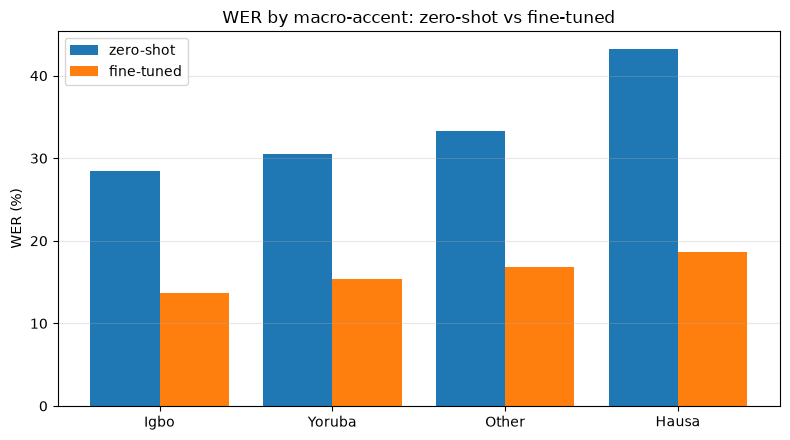

saved -> outputs/stt_whisper_turbo_results/wer_by_accent.png  (thesis Figure candidate)


In [7]:
import matplotlib.pyplot as plt

base = pd.read_csv(f"{RESULTS}/zeroshot/baseline_results.csv")
ft   = pd.read_csv(f"{RESULTS}/whisper_turbo_hf/results/finetuned_results.csv")
m = base.merge(ft, on=["group", "key"], suffixes=("_zs", "_ft"))
acc = m[m.group == "macro_accent"].sort_values("wer_zs")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(acc))
ax.bar([i - 0.2 for i in x], acc.wer_zs * 100, 0.4, label="zero-shot")
ax.bar([i + 0.2 for i in x], acc.wer_ft * 100, 0.4, label="fine-tuned")
ax.set_xticks(list(x)); ax.set_xticklabels(acc.key)
ax.set_ylabel("WER (%)"); ax.set_title("WER by macro-accent: zero-shot vs fine-tuned")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/stt_whisper_turbo_results/wer_by_accent.png", dpi=150)
plt.show()
print("saved -> outputs/stt_whisper_turbo_results/wer_by_accent.png  (thesis Figure candidate)")

## Layer 2 — live A/B demo

Runs the same audio through **base** and **base + adapter**. On a GPU this is
seconds per clip; on a laptop CPU expect ~1–3 minutes per clip (the model is
809M parameters) — keep `N_CLIPS` small locally.

In [8]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_CLIPS = 3 if DEVICE == "cuda" else 2
print(f"device: {DEVICE}" + ("  (CPU: each clip takes a minute or three — patience)" if DEVICE == "cpu" else ""))

device: cpu  (CPU: each clip takes a minute or three — patience)


In [9]:
from peft import PeftModel
from transformers import WhisperForConditionalGeneration, WhisperProcessor

processor = WhisperProcessor.from_pretrained(ADAPTER)
base = WhisperForConditionalGeneration.from_pretrained("openai/whisper-large-v3-turbo")
tuned = PeftModel.from_pretrained(
    WhisperForConditionalGeneration.from_pretrained("openai/whisper-large-v3-turbo"), ADAPTER)
print("models loaded")

c:\Users\John Michael\Desktop\Remote Engineer\sandbox\Neural Maze Courses\finetuning-course\0\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


models loaded


In [10]:
# Stream a few test clips from HF (audio decoded at 16 kHz; no full download).
from datasets import Audio, load_dataset

stream = (load_dataset("Johniblazee/naija-speech-afrispeech-ng", split="test", streaming=True)
          .cast_column("audio", Audio(sampling_rate=16000))
          .filter(lambda d: 0.5 <= d <= 30.0, input_columns="duration"))
clips = list(stream.shuffle(seed=7, buffer_size=200).take(N_CLIPS))
print(f"{len(clips)} clips streamed")

2 clips streamed


In [11]:
# The audio field's shape differs across `datasets` versions: a dict with
# 'array' (3.x decoded), raw {'bytes','path'} (undecoded), or a torchcodec
# decoder object (4.x). Normalise all three to 16 kHz float32 mono.
import io
import numpy as np

def audio_array(c, sr=16000):
    a = c["audio"]
    if isinstance(a, dict) and "array" in a:                  # datasets 3.x
        arr, in_sr = np.asarray(a["array"], dtype="float32"), a.get("sampling_rate", sr)
    elif isinstance(a, dict) and "bytes" in a:                # undecoded raw bytes
        import soundfile as sf
        arr, in_sr = sf.read(io.BytesIO(a["bytes"]), dtype="float32")
    elif hasattr(a, "get_all_samples"):                       # datasets 4.x torchcodec
        s = a.get_all_samples()
        arr, in_sr = s.data.numpy().astype("float32"), s.sample_rate
    else:
        raise TypeError(f"unrecognised audio field type: {type(a)}")
    if arr.ndim > 1:                                          # to mono
        arr = arr.mean(axis=0) if arr.shape[0] < arr.shape[-1] else arr.mean(axis=-1)
    if in_sr != sr:
        import librosa
        arr = librosa.resample(arr, orig_sr=in_sr, target_sr=sr)
    return arr

In [12]:
def transcribe(model, audio_array):
    model.to(DEVICE).eval()
    dtype = next(model.parameters()).dtype
    model.generation_config.max_length = None
    feats = processor.feature_extractor(
        audio_array, sampling_rate=16000, return_tensors="pt"
    ).input_features.to(device=DEVICE, dtype=dtype)
    with torch.no_grad():
        out = model.generate(input_features=feats, language="english",
                             task="transcribe", max_new_tokens=225)
    return processor.batch_decode(out, skip_special_tokens=True)[0]

import IPython.display as ipd
for c in clips:
    arr = audio_array(c)
    print(f"=== [{c['macro_accent']} | {c['domain']}] ===")
    print(f"  REF   : {c['text_raw']}")
    print(f"  before: {transcribe(base,  arr)}")
    print(f"  after : {transcribe(tuned, arr)}\n")
    display(ipd.Audio(arr, rate=16000))

=== [Other | general] ===
  REF   : Wild Wood Productions, a large group of musicians, are tuning up for their eighth annual benefit concert.



The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  before:  Wildwood Productions, the last group of musicians, are turning off for their eight annual benefits contract with us.
  after : widewood productions the last group of musicians are turning up for their sixth annual veneci concert



=== [Other | general] ===
  REF   : Gordon says yes, he was indicted for revealing classified information on a mass surveileince of Americans and he fled to a non-extradition country where he is currently hiding.
  before:  Gordon says he has come on. He was indicted for revealing classified information on the mass surveillance of Americans and he fled to a non-Ipene extradition country. Where is currently hiding? Who's talking?
  after : godon says yes he was indicted for revealing classified information on the mass surveillance of americans and he fled to a non extradition country where is currently hiding



### Your own voice

Record a short clip (any format librosa can read), set the path, run.

In [13]:
AUDIO_PATH = None   # e.g. r"C:\Users\you\recording.wav"

if AUDIO_PATH:
    import librosa
    audio, _ = librosa.load(AUDIO_PATH, sr=16000, mono=True)
    print(f"  before: {transcribe(base,  audio)}")
    print(f"  after : {transcribe(tuned, audio)}")
else:
    print("set AUDIO_PATH to try your own recording")

set AUDIO_PATH to try your own recording


## Layer 3 — other architectures, zero-shot, on the same clips (qualitative)

How do *other* existing models handle these exact clips, untrained on our corpus?

- **XLS-R (CTC):** the pretrained base has **no ASR head** and cannot transcribe;
  the comparable artifact is a community **English-CTC fine-tune** evaluated
  zero-shot on Nigerian speech (`jonatasgrosman/wav2vec2-xls-r-1b-english`, ~1B).
  Label it exactly that way anywhere it's reported.
- **Parakeet-TDT** (`nvidia/parakeet-tdt-0.6b-v3`): requires NVIDIA NeMo —
  **Colab/pod only** (NeMo does not realistically install on Windows).

This is a *qualitative* few-clip comparison. Citable WER numbers for these
architectures = the parked zero-shot sweep (scripts on a pod, ~1–2 GPU-hours).

In [14]:
# --- XLS-R English-CTC, zero-shot (works anywhere; ~4GB download, CPU-slow) ---
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

XLSR_ID = "jonatasgrosman/wav2vec2-xls-r-1b-english"
xlsr_proc = Wav2Vec2Processor.from_pretrained(XLSR_ID)
xlsr = Wav2Vec2ForCTC.from_pretrained(XLSR_ID).to(DEVICE).eval()

def transcribe_xlsr(audio_array):
    import torch as _t
    inputs = xlsr_proc(audio_array, sampling_rate=16000, return_tensors="pt")
    with _t.no_grad():
        logits = xlsr(inputs.input_values.to(DEVICE)).logits
    ids = logits.argmax(dim=-1)
    return xlsr_proc.batch_decode(ids)[0].lower()

for c in clips:
    arr = audio_array(c)
    print(f"=== [{c['macro_accent']} | {c['domain']}] ===")
    print(f"  REF               : {c['text_raw']}")
    print(f"  XLS-R-Eng (0-shot): {transcribe_xlsr(arr)}")
    print(f"  Whisper fine-tuned: {transcribe(tuned, arr)}\n")

c:\Users\John Michael\Desktop\Remote Engineer\sandbox\Neural Maze Courses\finetuning-course\0\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\John Michael\.cache\huggingface\hub\models--jonatasgrosman--wav2vec2-xls-r-1b-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


=== [Other | general] ===
  REF               : Wild Wood Productions, a large group of musicians, are tuning up for their eighth annual benefit concert.

  XLS-R-Eng (0-shot): wildewood potosons coa the large group of musicans coma atoni of prodas eak annual venefic concert io
  Whisper fine-tuned: widewood productions the last group of musicians are turning up for their sixth annual veneci concert

=== [Other | general] ===
  REF               : Gordon says yes, he was indicted for revealing classified information on a mass surveileince of Americans and he fled to a non-extradition country where he is currently hiding.
  XLS-R-Eng (0-shot): gotton sis years command he was indicted for revealing classified information on the massovilands of americans and it fled to the non ipin extraditional country where is currectly ide
  Whisper fine-tuned: godon says yes he was indicted for revealing classified information on the mass surveillance of americans and he fled to a non extradition coun

In [15]:
# --- Parakeet-TDT zero-shot (COLAB/POD ONLY: needs NeMo; skipped gracefully) ---
try:
    import nemo.collections.asr as nemo_asr  # pip install -q "nemo_toolkit[asr]"
except ImportError:
    nemo_asr = None
    print("NeMo not installed - run on Colab/pod with:  pip install -q nemo_toolkit[asr]")

if nemo_asr:
    import soundfile as sf, tempfile, os as _os
    parakeet = nemo_asr.models.ASRModel.from_pretrained("nvidia/parakeet-tdt-0.6b-v3")
    tmpdir = tempfile.mkdtemp(prefix="parakeet_clips_")   # private dir, no name collisions
    paths = []
    for i, c in enumerate(clips):   # NeMo transcribes from files
        p = _os.path.join(tmpdir, f"clip{i}.wav")
        sf.write(p, audio_array(c), 16000)
        paths.append(p)
    outs = parakeet.transcribe(paths)
    for c, o in zip(clips, outs):
        print(f"=== [{c['macro_accent']}] ===")
        print(f"  REF               : {c['text_raw']}")
        print(f"  Parakeet (0-shot) : {getattr(o, 'text', o)}")
        print(f"  Whisper fine-tuned: {transcribe(tuned, audio_array(c))}\n")

NeMo not installed - run on Colab/pod with:  pip install -q nemo_toolkit[asr]
